# Sea-State Direction Heatmaps and Clip Candidate Timestamps

Standalone notebook for the new collection plan.

It loads yearly buoy text files, computes `sea_state = H^2 * T`, classifies wave direction into the three direction groups for each location, makes 10 sea-state bins per direction group, plots availability heatmaps, and lists two candidate timestamps per bin for selecting 10-minute webcam clips.

## Collection Targets

- 2 locations
- 3 direction groups per location
- 10 sea-state bins per direction group
- 2 candidate clips per bin
- Target total: 120 candidate 10-minute clips

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_rows", 140)
pd.set_option("display.max_columns", 30)

# Run this notebook from save_predict/shoreline_jsons, or update these paths.
# Current available files in this project folder:
#   ./buoy/jennettespier2025.txt
#   ./buoy/santacruz2025.txt
# If you add a Seabright-specific file, replace seabright's file_path below.
LOCATION_CONFIGS = {
    "jennettes_pier": {
        "display_name": "Jennette's Pier",
        "file_path": "./buoy/jennettespier2025.txt",
        "beach_facing_degrees": 65,
        "direction_groups": [
            {"name": "north_easterly_onshore", "label": "NE onshore", "final_plot_group": "onshore", "start": 335, "end": 65},
            {"name": "south_easterly_onshore", "label": "SE onshore", "final_plot_group": "onshore", "start": 65, "end": 155},
            {"name": "offshore", "label": "Offshore", "final_plot_group": "offshore", "start": 155, "end": 335},
        ],
        "clean_offshore": (180, 270),
    },
    "seabright": {
        "display_name": "Seabright",
        "file_path": "./buoy/santacruz2025.txt",
        "beach_facing_degrees": 194,
        "direction_groups": [
            {"name": "south_easterly_onshore", "label": "SE onshore", "final_plot_group": "onshore", "start": 104, "end": 194},
            {"name": "south_westerly_onshore", "label": "SW onshore", "final_plot_group": "onshore", "start": 194, "end": 284},
            {"name": "offshore", "label": "Offshore", "final_plot_group": "offshore", "start": 284, "end": 104},
        ],
        "clean_offshore": (300, 45),
    },
}

TARGET_BINS = 10
CLIPS_PER_BIN = 2
NDBC_COLUMNS = ["YY", "MM", "DD", "hh", "mm", "WDIR", "WSPD", "GST", "WVHT", "DPD", "APD", "MWD", "PRES", "ATMP", "WTMP", "DEWP", "VIS", "TIDE"]
MISSING_VALUES = [99, 99.0, 999, 999.0, 9999, 9999.0]

## Helper Functions

In [2]:
def in_direction_range(direction, start, end):
    """Inclusive compass interval. Handles ranges that cross 0 degrees."""
    if pd.isna(direction):
        return False

    direction = float(direction) % 360
    start = start % 360
    end = end % 360

    if start <= end:
        return start <= direction <= end
    return direction >= start or direction <= end


def load_buoy_file(file_path):
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(
            f"Buoy file not found: {path.resolve()}\n"
            "Run this notebook from save_predict/shoreline_jsons, or update LOCATION_CONFIGS file_path values."
        )

    with path.open("r") as f:
        first_header = f.readline().strip()

    columns = first_header.lstrip("#").split()
    if not columns or columns[0] not in {"YY", "yr"}:
        columns = NDBC_COLUMNS

    buoy = pd.read_csv(path, sep=r"\s+", comment="#", names=columns)
    buoy = buoy.rename(columns={"yr": "YY", "mo": "MM", "dy": "DD", "hr": "hh", "mn": "mm"})

    for col in ["YY", "MM", "DD", "hh", "mm", "WVHT", "DPD", "MWD"]:
        buoy[col] = pd.to_numeric(buoy[col], errors="coerce")

    for col in ["WVHT", "DPD", "MWD"]:
        buoy[col] = buoy[col].replace(MISSING_VALUES, np.nan)

    buoy["timestamp"] = pd.to_datetime(
        dict(year=buoy["YY"], month=buoy["MM"], day=buoy["DD"], hour=buoy["hh"], minute=buoy["mm"]),
        errors="coerce",
    )

    buoy = buoy.dropna(subset=["timestamp", "WVHT", "DPD", "MWD"]).copy()
    buoy["sea_state"] = (buoy["WVHT"] ** 2) * buoy["DPD"]
    buoy = buoy.rename(columns={"WVHT": "H", "DPD": "T", "MWD": "direction_degrees"})
    return buoy.sort_values("timestamp").reset_index(drop=True)


def classify_direction(direction, config):
    for group in config["direction_groups"]:
        if in_direction_range(direction, group["start"], group["end"]):
            return group["name"], group["label"], group["final_plot_group"]
    return np.nan, np.nan, np.nan


def add_direction_metadata(buoy, config):
    classified = buoy["direction_degrees"].apply(lambda deg: classify_direction(deg, config))
    buoy[["direction_group", "direction_label", "final_plot_group"]] = pd.DataFrame(classified.tolist(), index=buoy.index)

    clean_start, clean_end = config["clean_offshore"]
    buoy["clean_offshore"] = buoy["direction_degrees"].apply(lambda deg: in_direction_range(deg, clean_start, clean_end))

    # Use all onshore records. For offshore, keep only the preferred clean range.
    buoy["usable_for_selection"] = (buoy["direction_group"] != "offshore") | buoy["clean_offshore"]
    return buoy.dropna(subset=["direction_group"]).copy()


def assign_quantile_bins(group_df, target_bins=TARGET_BINS):
    n_bins = min(target_bins, len(group_df))
    ranked = group_df["sea_state"].rank(method="first")
    return pd.qcut(ranked, q=n_bins, labels=range(1, n_bins + 1)).astype(int)


def pick_clip_candidates(bin_df, clips_per_bin=CLIPS_PER_BIN):
    ordered = bin_df.sort_values(["sea_state", "timestamp"]).reset_index(drop=True)
    if len(ordered) <= clips_per_bin:
        return ordered

    # Choose representative timestamps spread inside the bin, avoiding exact bin edges.
    positions = np.linspace(0, len(ordered) - 1, clips_per_bin + 2)[1:-1]
    positions = np.unique(np.round(positions).astype(int))
    return ordered.iloc[positions]


def build_binned_records(location, config):
    buoy = load_buoy_file(config["file_path"])
    buoy = add_direction_metadata(buoy, config)
    usable = buoy[buoy["usable_for_selection"]].copy()
    usable["location"] = location

    binned_parts = []
    group_order = [group["name"] for group in config["direction_groups"]]

    for direction_group in group_order:
        group_df = usable[usable["direction_group"] == direction_group].copy()
        if group_df.empty:
            continue

        group_df["sea_state_bin"] = assign_quantile_bins(group_df)
        bin_stats = (
            group_df.groupby("sea_state_bin", as_index=False)["sea_state"]
            .agg(bin_min="min", bin_max="max", bin_count="size")
        )
        group_df = group_df.merge(bin_stats, on="sea_state_bin", how="left")
        binned_parts.append(group_df)

    if not binned_parts:
        raise ValueError(f"No usable records found for {location}.")

    return pd.concat(binned_parts, ignore_index=True)


def build_candidate_table(binned):
    candidate_parts = []
    for (_, direction_group, sea_state_bin), bin_df in binned.groupby(["location", "direction_group", "sea_state_bin"], sort=True):
        chosen = pick_clip_candidates(bin_df).copy()
        chosen["candidate_rank"] = range(1, len(chosen) + 1)
        candidate_parts.append(chosen)

    candidates = pd.concat(candidate_parts, ignore_index=True)
    candidates = candidates[
        [
            "location",
            "timestamp",
            "direction_degrees",
            "direction_group",
            "final_plot_group",
            "H",
            "T",
            "sea_state",
            "sea_state_bin",
            "bin_min",
            "bin_max",
            "bin_count",
            "candidate_rank",
        ]
    ]
    return candidates.sort_values(["location", "direction_group", "sea_state_bin", "candidate_rank"]).reset_index(drop=True)


def plot_availability_heatmap(binned, location, config):
    group_order = [group["name"] for group in config["direction_groups"]]
    group_labels = {group["name"]: group["label"] for group in config["direction_groups"]}

    heatmap_counts = (
        binned.pivot_table(
            index="direction_group",
            columns="sea_state_bin",
            values="timestamp",
            aggfunc="count",
            fill_value=0,
        )
        .reindex(group_order)
        .reindex(columns=range(1, TARGET_BINS + 1), fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(13, 3.8))
    im = ax.imshow(heatmap_counts.values, aspect="auto", cmap="YlGnBu")

    ax.set_title(f"{config['display_name']}: usable buoy timestamps by direction and sea-state bin")
    ax.set_xlabel("Sea-state quantile bin, low to high")
    ax.set_ylabel("Direction group")
    ax.set_xticks(np.arange(TARGET_BINS))
    ax.set_xticklabels(range(1, TARGET_BINS + 1))
    ax.set_yticks(np.arange(len(heatmap_counts.index)))
    ax.set_yticklabels([group_labels.get(group, group) for group in heatmap_counts.index])

    for row_i in range(heatmap_counts.shape[0]):
        for col_i in range(heatmap_counts.shape[1]):
            value = int(heatmap_counts.iloc[row_i, col_i])
            ax.text(col_i, row_i, value, ha="center", va="center", color="black", fontsize=9)

    fig.colorbar(im, ax=ax, label="Available buoy timestamps")
    plt.tight_layout()
    plt.show()

    return heatmap_counts

## Generate Heatmaps and Candidate Timestamp Tables

Loading and binning Jennette's Pier from ./buoy/jennettespier2025.txt


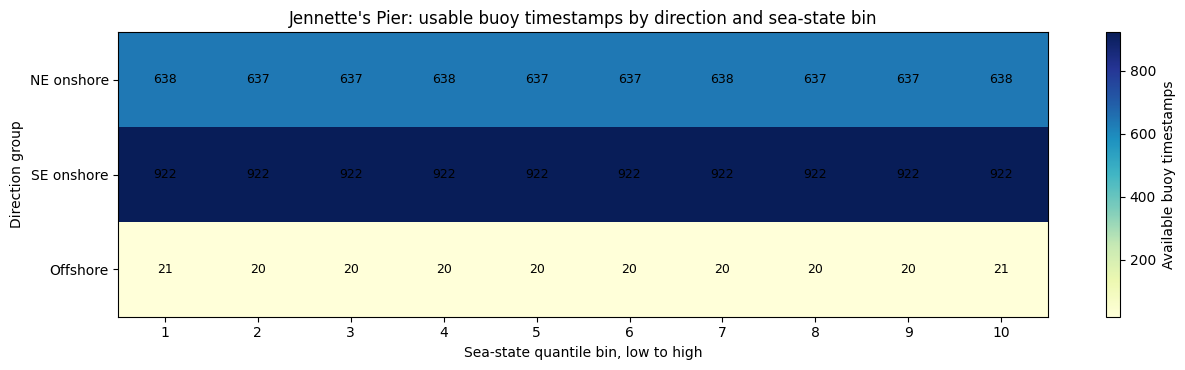

Jennette's Pier candidate timestamps


,location,timestamp,direction_degrees,direction_group,final_plot_group,H,T,sea_state,sea_state_bin,bin_min,bin_max,bin_count,candidate_rank
0,jennettes_pier,2025-11-24 07:56:00,55.0,north_easterly_onshore,onshore,0.63,6.67,2.647323,1,0.605952,4.124064,638,1
1,jennettes_pier,2025-05-20 14:56:00,359.0,north_easterly_onshore,onshore,0.88,4.35,3.368640,1,0.605952,4.124064,638,2
2,jennettes_pier,2025-01-03 11:26:00,338.0,north_easterly_onshore,onshore,1.01,4.76,4.855676,2,4.140500,6.250000,637,1
3,jennettes_pier,2025-04-10 16:56:00,47.0,north_easterly_onshore,onshore,1.08,4.76,5.552064,2,4.140500,6.250000,637,2
4,jennettes_pier,2025-08-12 15:56:00,65.0,north_easterly_onshore,onshore,0.79,11.11,6.933751,3,6.250000,8.547056,637,1
5,jennettes_pier,2025-12-05 07:56:00,17.0,north_easterly_onshore,onshore,1.27,4.76,7.677404,3,6.250000,8.547056,637,2
6,jennettes_pier,2025-02-22 06:26:00,24.0,north_easterly_onshore,onshore,1.20,6.67,9.604800,4,8.547056,11.831508,638,1
7,jennettes_pier,2025-04-08 22:56:00,12.0,north_easterly_onshore,onshore,1.35,5.88,10.716300,4,8.547056,11.831508,638,2
8,jennettes_pier,2025-01-12 17:56:00,37.0,north_easterly_onshore,onshore,1.35,7.14,13.012650,5,11.831508,15.818572,637,1
9,jennettes_pier,2025-01-24 20:26:00,57.0,north_easterly_onshore,onshore,1.17,10.53,14.414517,5,11.831508,15.818572,637,2


Loading and binning Seabright from ./buoy/santacruz2025.txt


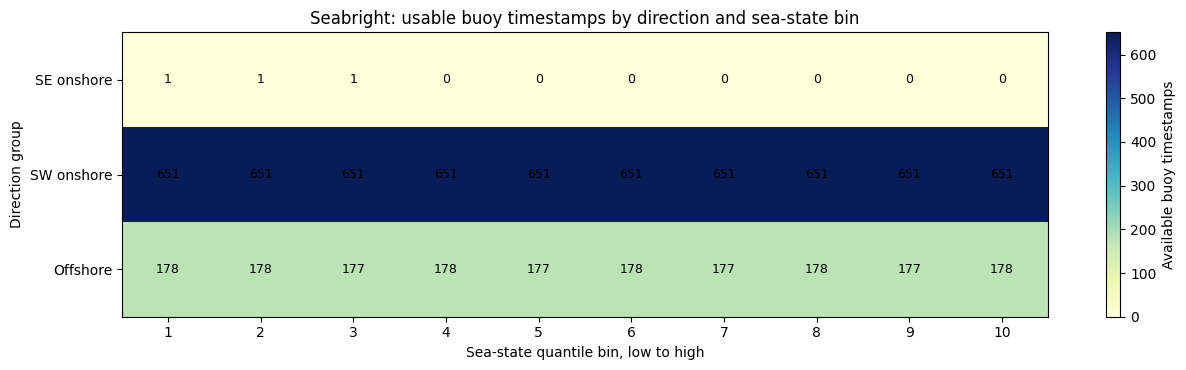

Seabright candidate timestamps


,location,timestamp,direction_degrees,direction_group,final_plot_group,H,T,sea_state,sea_state_bin,bin_min,bin_max,bin_count,candidate_rank
0,seabright,2025-12-30 12:56:00,307,offshore,offshore,0.74,8.33,4.561508,1,1.582700,6.375625,178,1
1,seabright,2025-08-06 15:26:00,306,offshore,offshore,0.97,5.88,5.532492,1,1.582700,6.375625,178,2
2,seabright,2025-08-02 19:26:00,306,offshore,offshore,1.00,7.14,7.140000,2,6.375625,8.666532,178,1
3,seabright,2025-08-21 13:56:00,301,offshore,offshore,1.06,7.14,8.022504,2,6.375625,8.666532,178,2
4,seabright,2025-08-18 20:26:00,304,offshore,offshore,0.97,9.88,9.296092,3,8.666532,10.320453,177,1
5,seabright,2025-04-19 13:56:00,300,offshore,offshore,1.04,9.09,9.831744,3,8.666532,10.320453,177,2
6,seabright,2025-09-25 05:26:00,301,offshore,offshore,0.99,11.11,10.888911,4,10.320453,12.510693,178,1
7,seabright,2025-10-11 10:56:00,301,offshore,offshore,1.09,9.88,11.738428,4,10.320453,12.510693,178,2
8,seabright,2025-10-09 03:56:00,301,offshore,offshore,1.00,13.33,13.330000,5,12.599296,14.911533,177,1
9,seabright,2025-12-29 14:26:00,303,offshore,offshore,1.16,10.53,14.169168,5,12.599296,14.911533,177,2


Combined candidate rows: 103
Expected target rows: 120


,location,timestamp,direction_degrees,direction_group,final_plot_group,H,T,sea_state,sea_state_bin,bin_min,bin_max,bin_count,candidate_rank
0,jennettes_pier,2025-11-24 07:56:00,55.0,north_easterly_onshore,onshore,0.63,6.67,2.647323,1,0.605952,4.124064,638,1
1,jennettes_pier,2025-05-20 14:56:00,359.0,north_easterly_onshore,onshore,0.88,4.35,3.368640,1,0.605952,4.124064,638,2
2,jennettes_pier,2025-01-03 11:26:00,338.0,north_easterly_onshore,onshore,1.01,4.76,4.855676,2,4.140500,6.250000,637,1
3,jennettes_pier,2025-04-10 16:56:00,47.0,north_easterly_onshore,onshore,1.08,4.76,5.552064,2,4.140500,6.250000,637,2
4,jennettes_pier,2025-08-12 15:56:00,65.0,north_easterly_onshore,onshore,0.79,11.11,6.933751,3,6.250000,8.547056,637,1
5,jennettes_pier,2025-12-05 07:56:00,17.0,north_easterly_onshore,onshore,1.27,4.76,7.677404,3,6.250000,8.547056,637,2
6,jennettes_pier,2025-02-22 06:26:00,24.0,north_easterly_onshore,onshore,1.20,6.67,9.604800,4,8.547056,11.831508,638,1
7,jennettes_pier,2025-04-08 22:56:00,12.0,north_easterly_onshore,onshore,1.35,5.88,10.716300,4,8.547056,11.831508,638,2
8,jennettes_pier,2025-01-12 17:56:00,37.0,north_easterly_onshore,onshore,1.35,7.14,13.012650,5,11.831508,15.818572,637,1
9,jennettes_pier,2025-01-24 20:26:00,57.0,north_easterly_onshore,onshore,1.17,10.53,14.414517,5,11.831508,15.818572,637,2


In [3]:
all_binned_records = []
all_candidate_tables = []
heatmap_count_tables = {}

for location, config in LOCATION_CONFIGS.items():
    print(f"Loading and binning {config['display_name']} from {config['file_path']}")
    binned = build_binned_records(location, config)
    all_binned_records.append(binned)

    heatmap_count_tables[location] = plot_availability_heatmap(binned, location, config)

    candidates = build_candidate_table(binned)
    all_candidate_tables.append(candidates)

    print(f"{config['display_name']} candidate timestamps")
    display(candidates)

binned_buoy_records = pd.concat(all_binned_records, ignore_index=True)
candidate_clip_table = pd.concat(all_candidate_tables, ignore_index=True)

print("Combined candidate rows:", len(candidate_clip_table))
print("Expected target rows:", len(LOCATION_CONFIGS) * 3 * TARGET_BINS * CLIPS_PER_BIN)
display(candidate_clip_table)

## Optional CSV Exports

In [4]:
output_dir = Path("./candidate_clip_outputs")
output_dir.mkdir(exist_ok=True)

candidate_clip_table.to_csv(output_dir / "candidate_clip_table.csv", index=False)
binned_buoy_records.to_csv(output_dir / "binned_buoy_records.csv", index=False)

for location, heatmap_counts in heatmap_count_tables.items():
    heatmap_counts.to_csv(output_dir / f"{location}_heatmap_counts.csv")

print(f"Saved CSV outputs to {output_dir.resolve()}")

Saved CSV outputs to C:\Users\monaz\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\candidate_clip_outputs
